e:\InstagramReachAnalysis\.venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveRegressor is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDRegressor(loss='epsilon_insensitive', penalty=None, learning_rate='pa1', eta0 = 1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
e:\InstagramReachAnalysis\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
e:\InstagramReachAnalysis\.venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveRegressor is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDRegressor(loss='epsilon_insensitive', penalty=None, learning_rate='pa1', eta0 = 1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


C = 0.001  | R² = 0.8690 | MAE = 1019.67
C = 0.01   | R² = 0.8782 | MAE = 1005.24
C = 0.1    | R² = 0.8781 | MAE = 1004.93
C = 1      | R² = 0.8777 | MAE = 1006.84
C = 10     | R² = 0.8801 | MAE = 1019.00


e:\InstagramReachAnalysis\.venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveRegressor is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDRegressor(loss='epsilon_insensitive', penalty=None, learning_rate='pa1', eta0 = 1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
e:\InstagramReachAnalysis\.venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveRegressor is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDRegressor(loss='epsilon_insensitive', penalty=None, learning_rate='pa1', eta0 = 1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
e:\InstagramReachAnalysis\.venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveRegressor is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDRegressor(loss='epsilon_insensitive', penalty=None, learning_rate='pa

C = 100    | R² = 0.8796 | MAE = 1113.60


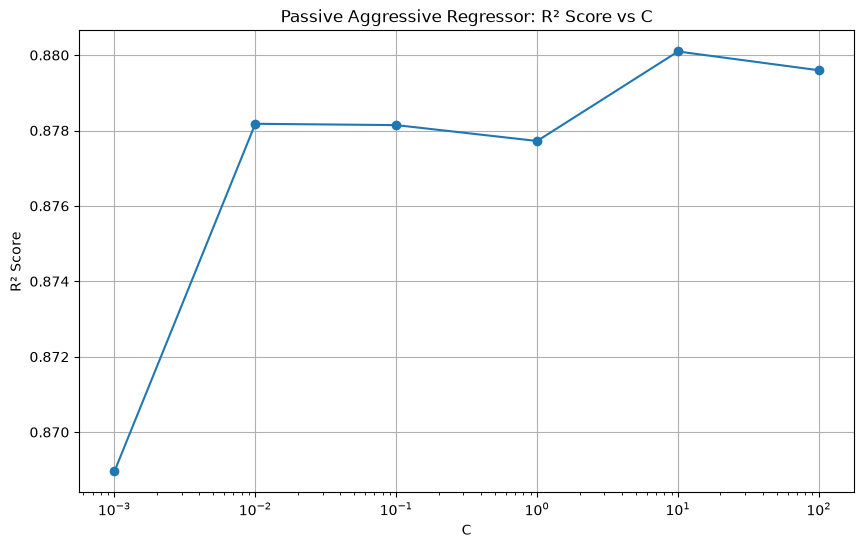

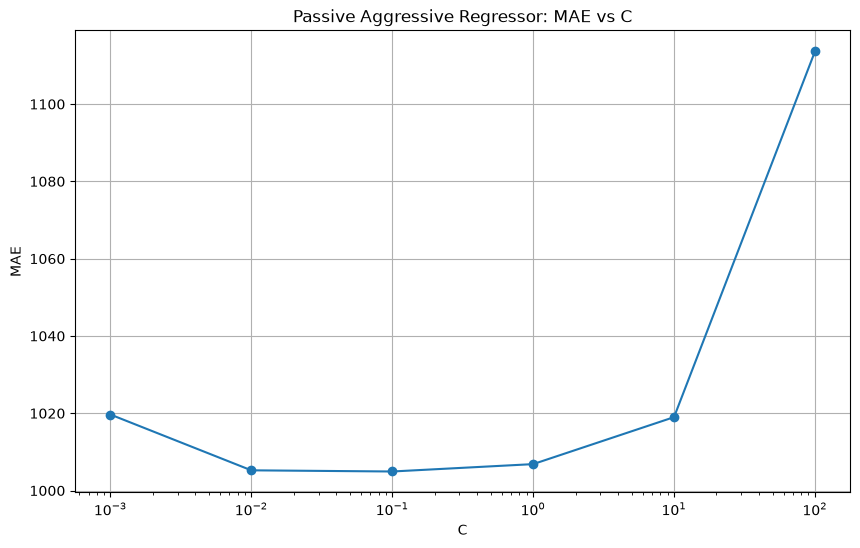

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PassiveAggressiveRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Import dataset
instagram_data = pd.read_csv("datasets/instagram_new_data.csv", encoding = "utf-8-sig")
x = np.array(instagram_data[['Likes', 'Saves', 'Comments', 'Shares', 'Profile Visits', 'Follows']])
y = np.array(instagram_data["Impressions"])

def compare_passive_aggressive_C(x, y):

    # Các giá trị C muốn thử
    C_values = [0.001, 0.01, 0.1, 1, 10, 100]

    # Chia dữ liệu
    xtrain, xtest, ytrain, ytest = train_test_split(
        x,
        y,
        test_size=0.2,
        random_state=42
    )

    # Chuẩn hóa
    scaler = StandardScaler()
    xtrain = scaler.fit_transform(xtrain)
    xtest = scaler.transform(xtest)

    r2_scores = []
    mae_scores = []

    # Training với từng C
    for C in C_values:
        model = PassiveAggressiveRegressor(
            C=C,
            epsilon=0.1,
            random_state=42
        )

        model.fit(xtrain, ytrain)

        # Dự đoán
        y_pred = model.predict(xtest)

        # Đánh giá
        r2 = r2_score(ytest, y_pred)
        mae = mean_absolute_error(ytest, y_pred)

        r2_scores.append(r2)
        mae_scores.append(mae)

        print(
            f"C = {C:<6} | "
            f"R² = {r2:.4f} | "
            f"MAE = {mae:.2f}"
        )

    # ==============================
    # Vẽ biểu đồ R² theo C
    # ==============================

    plt.figure(figsize=(10, 6))

    plt.plot(
        C_values,
        r2_scores,
        marker='o'
    )

    plt.xscale('log')

    plt.xlabel("C")
    plt.ylabel("R² Score")
    plt.title(
        "Passive Aggressive Regressor: R² Score vs C"
    )

    plt.grid(True)

    plt.show()

    # ==============================
    # Vẽ biểu đồ MAE theo C
    # ==============================

    plt.figure(figsize=(10, 6))

    plt.plot(
        C_values,
        mae_scores,
        marker='o'
    )

    plt.xscale('log')

    plt.xlabel("C")
    plt.ylabel("MAE")
    plt.title(
        "Passive Aggressive Regressor: MAE vs C"
    )

    plt.grid(True)

    plt.show()

if __name__ == "__main__":
    compare_passive_aggressive_C(x, y)